In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [6]:
#distinguir jogador pela sua camiseta
image_path = "../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

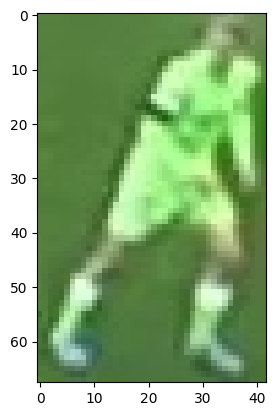

In [7]:
plt.imshow(image)
plt.show()

# Take the top half of the image

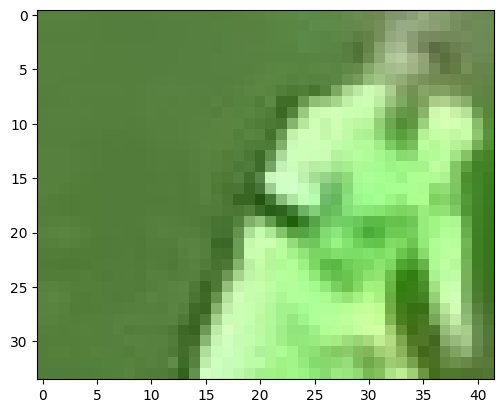

In [8]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)

# Cluster the image into two clusters (separar cor da camisa do fundo)

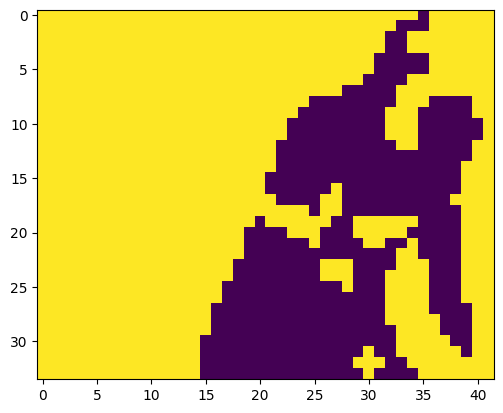

In [10]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the orginal image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [ ]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster) # o que nao é player é cluster 1

1


In [ ]:
player_cluster = 1-non_player_cluster
print(player_cluster) # o que é player é cluster 0

0


In [ ]:
kmeans.cluster_centers_[player_cluster] #rgbcolor - green cor da camiseta

array([169.10609481, 233.16930023, 143.25733634])